Saved: commuta_pm25_co2.png + .svg


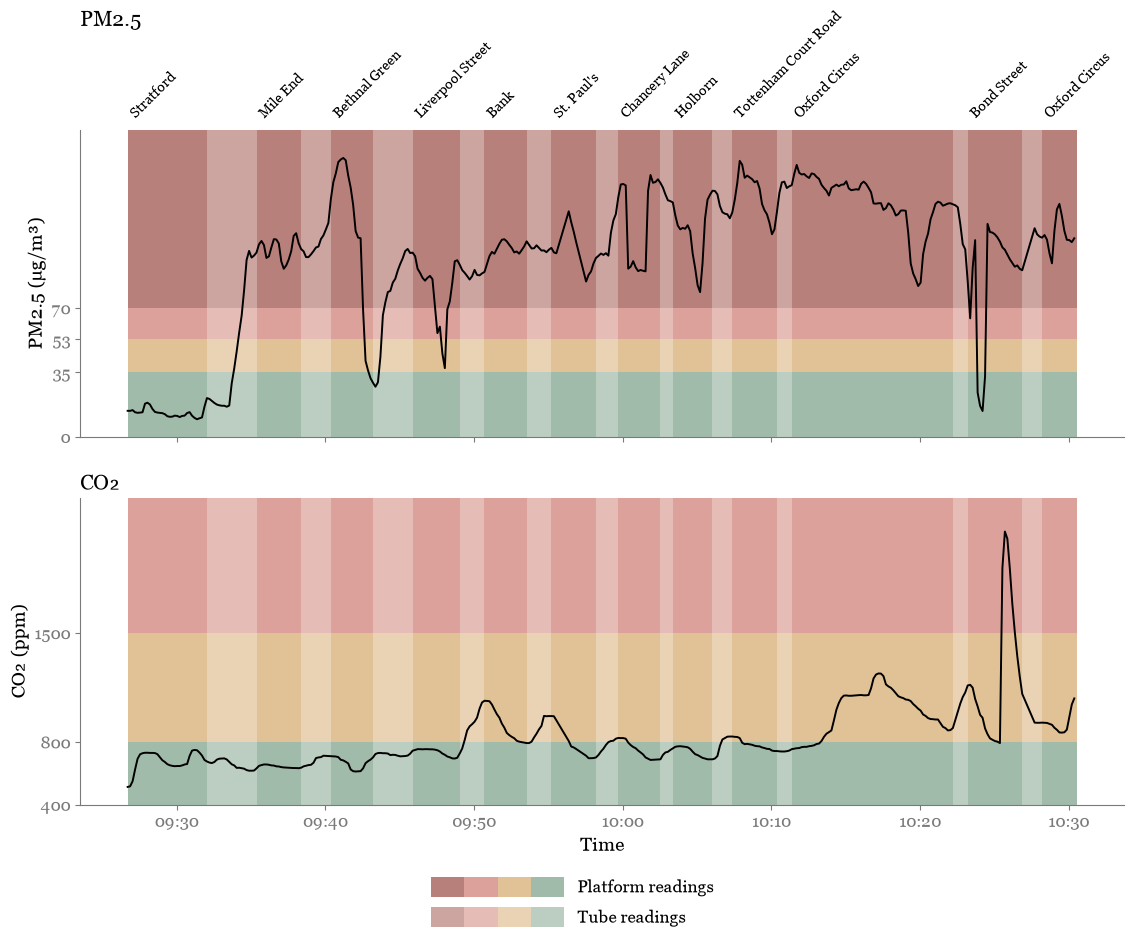

In [17]:
"""
Commuta — PM2.5 and CO₂ exposure with DAQI-style bands
Platform segments = same colours at alpha 0.6; tube = alpha 0.4.
Filters to sequence_number 4829-5211.
"""

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from matplotlib.transforms import blended_transform_factory
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

# ==================== CONFIG ====================
FILE = "../data/commuta_readings_20260710.xlsx"
SEQ_MIN, SEQ_MAX = 4829, 5211

# DAQI band RGB only — alpha applied per-segment below
BAND_LOW_RGB   = (122/255, 158/255, 135/255)   # green (good)
BAND_MID_RGB   = (212/255, 169/255, 106/255)   # amber (moderate)
BAND_HIGH_RGB  = (204/255, 122/255, 111/255)   # rose (high)
BAND_VHIGH_RGB = (155/255,  74/255,  66/255)   # deep red (very high)

ALPHA_PLATFORM = 0.7
ALPHA_TUBE     = 0.5

BLACK = "#000000"
GREY  = "#7A7A7A"

# ==================== LOAD & FILTER ====================
df = pd.read_excel(FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("sequence_number").reset_index(drop=True)
df = df[(df["sequence_number"] >= SEQ_MIN) &
        (df["sequence_number"] <= SEQ_MAX)].reset_index(drop=True)

# ==================== SEGMENTS ====================
# Every stretch of same station_name (including NaN stretches = tube).
station_key = df["station_name"].fillna("__NONE__")
df["group_id"] = (station_key != station_key.shift()).cumsum()

segments = (df.groupby("group_id")
              .agg(station=("station_name", "first"),
                   start=("timestamp", "first"),
                   end=("timestamp", "last"))
              .reset_index(drop=True))

# For seamless tiling, extend each segment's shading to the next segment's start
sample_interval = pd.Timedelta(seconds=10)
segments["shade_end"] = segments["start"].shift(-1)
segments.loc[segments.index[-1], "shade_end"] = (
    segments["end"].iloc[-1] + sample_interval
)

# ==================== STYLE ====================
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Fraunces", "Georgia", "Times New Roman", "DejaVu Serif"],
    "axes.labelsize":    14,
    "axes.labelcolor":   BLACK,
    "xtick.labelsize":   12,
    "ytick.labelsize":   12,
    "xtick.color":       GREY,
    "ytick.color":       GREY,
    "axes.edgecolor":    GREY,
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

# ==================== FIGURE ====================
fig, (ax_pm, ax_co2) = plt.subplots(
    2, 1, figsize=(12, 9.5), sharex=True,
    gridspec_kw={"hspace": 0.2}
)

pm_top  = max(df["pm25"].max() * 1.10, 100)
co2_top = max(df["co2"].max()  * 1.10, 2000)
ax_pm.set_ylim(0, pm_top)
ax_co2.set_ylim(400, co2_top)

pm_bands = [
    (0,  35,     BAND_LOW_RGB),
    (35, 53,     BAND_MID_RGB),
    (53, 70,     BAND_HIGH_RGB),
    (70, pm_top, BAND_VHIGH_RGB),
]
co2_bands = [
    (400,  800,     BAND_LOW_RGB),
    (800,  1500,    BAND_MID_RGB),
    (1500, co2_top, BAND_HIGH_RGB),
]

# ---------- Draw DAQI bands per segment at the correct alpha ----------
def draw_bands(ax, x_start, x_end, bands, alpha):
    for y_bot, y_top, rgb in bands:
        ax.fill_between([x_start, x_end], y_bot, y_top,
                        color=rgb, alpha=alpha,
                        zorder=0, edgecolor="none", linewidth=0)

for _, seg in segments.iterrows():
    alpha = ALPHA_PLATFORM if pd.notna(seg["station"]) else ALPHA_TUBE
    draw_bands(ax_pm,  seg["start"], seg["shade_end"], pm_bands,  alpha)
    draw_bands(ax_co2, seg["start"], seg["shade_end"], co2_bands, alpha)

# ---------- Data lines on top ----------
ax_pm.plot(df["timestamp"],  df["pm25"], color=BLACK, lw=1.4, zorder=3)
ax_co2.plot(df["timestamp"], df["co2"],  color=BLACK, lw=1.4, zorder=3)

# ---------- Y-axis ----------
ax_pm.set_yticks([0, 35, 53, 70])
ax_pm.set_ylabel("PM2.5 (µg/m³)")
ax_pm.set_title("PM2.5", color=BLACK, loc="left", fontsize=15, pad=75)

ax_co2.set_yticks([400, 800, 1500])
ax_co2.set_ylabel("CO₂ (ppm)")
ax_co2.set_title("CO₂", color=BLACK, loc="left", fontsize=15)

# ---------- Station name labels ----------
tr_pm = blended_transform_factory(ax_pm.transData, ax_pm.transAxes)
platform_segments = segments[segments["station"].notna()]
for _, seg in platform_segments.iterrows():
    ax_pm.text(seg["start"], 1.03, seg["station"],
               transform=tr_pm, rotation=45, fontsize=10,
               ha="left", va="bottom", color=BLACK, clip_on=False)

# ---------- X-axis ----------
ax_co2.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax_co2.set_xlabel("Time")

# ---------- Layout ----------
fig.subplots_adjust(top=0.86, bottom=0.15, left=0.09, right=0.96)

# ==================== LEGEND ====================
# Order: dark red (very high) → red (high) → amber (mid) → green (low)
band_order = [BAND_VHIGH_RGB, BAND_HIGH_RGB, BAND_MID_RGB, BAND_LOW_RGB]

platform_group = tuple(
    Patch(facecolor=rgb, alpha=ALPHA_PLATFORM, edgecolor='none')
    for rgb in band_order
)
tube_group = tuple(
    Patch(facecolor=rgb, alpha=ALPHA_TUBE, edgecolor='none')
    for rgb in band_order
)

fig.legend(
    [platform_group, tube_group],
    ["Platform readings", "Tube readings"],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    frameon=False,
    fontsize=12,
    handlelength=8,
    handleheight=1.5,
    labelspacing=0.6,
)

# ---------- Save ----------
plt.savefig("../figures/commuta_pm25_co2.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("../figures/commuta_pm25_co2.svg", bbox_inches="tight", facecolor="white")
print("Saved: commuta_pm25_co2.png + .svg")